In [56]:
%pip install tensorflow --quiet
# Import modules for analysis.
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout


import warnings
warnings.filterwarnings('ignore')

Note: you may need to restart the kernel to use updated packages.


In [57]:
# Set default plot size.
plt.rcParams['figure.figsize'] = (10,5)


In [58]:
# Import data and view the first five rows.
heart_ds = pd.read_csv("/Users/michaelperrine/Library/CloudStorage/OneDrive-Personal/Projects/heart_disease.csv")
heart_ds.head()


,Age,Gender,Blood Pressure,Cholesterol Level,Exercise Habits,Smoking,Family Heart Disease,Diabetes,BMI,High Blood Pressure,...,High LDL Cholesterol,Alcohol Consumption,Stress Level,Sleep Hours,Sugar Consumption,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Heart Disease Status
0,56.0,Male,153.0,155.0,High,Yes,Yes,No,24.991591,Yes,...,No,High,Medium,7.633228,Medium,342.0,NaN,12.969246,12.387250,No
1,69.0,Female,146.0,286.0,High,No,Yes,Yes,25.221799,No,...,No,Medium,High,8.744034,Medium,133.0,157.0,9.355389,19.298875,No
2,46.0,Male,126.0,216.0,Low,No,No,No,29.855447,No,...,Yes,Low,Low,4.440440,Low,393.0,92.0,12.709873,11.230926,No
3,32.0,Female,122.0,293.0,High,Yes,Yes,No,24.130477,Yes,...,Yes,Low,High,5.249405,High,293.0,94.0,12.509046,5.961958,No
4,60.0,Male,166.0,242.0,Low,Yes,Yes,Yes,20.486289,Yes,...,No,Low,High,7.030971,High,263.0,154.0,10.381259,8.153887,No


In [59]:
# View the dimensions of the data.
print(f" The dimesions of the Heart Diseas data is: \n {heart_ds.shape}")

 The dimesions of the Heart Diseas data is: 
 (10000, 21)


In [60]:
# The null value counts in the data set.
print(f" The null values counts in the data are:\n {heart_ds.isnull().sum().sort_values(ascending=False)}")

 The null values counts in the data are:
 Alcohol Consumption     2586
Cholesterol Level         30
Sugar Consumption         30
Diabetes                  30
Age                       29
High LDL Cholesterol      26
CRP Level                 26
Triglyceride Level        26
High Blood Pressure       26
Sleep Hours               25
Low HDL Cholesterol       25
Smoking                   25
Exercise Habits           25
BMI                       22
Stress Level              22
Fasting Blood Sugar       22
Family Heart Disease      21
Homocysteine Level        20
Gender                    19
Blood Pressure            19
Heart Disease Status       0
dtype: int64


In [61]:
# View percentage of missing values.

print(f" The null values counts in the data are:\n {(heart_ds.isnull().mean() * 100).sort_values(ascending=False)}")

 The null values counts in the data are:
 Alcohol Consumption     25.86
Cholesterol Level        0.30
Sugar Consumption        0.30
Diabetes                 0.30
Age                      0.29
High LDL Cholesterol     0.26
CRP Level                0.26
Triglyceride Level       0.26
High Blood Pressure      0.26
Sleep Hours              0.25
Low HDL Cholesterol      0.25
Smoking                  0.25
Exercise Habits          0.25
BMI                      0.22
Stress Level             0.22
Fasting Blood Sugar      0.22
Family Heart Disease     0.21
Homocysteine Level       0.20
Gender                   0.19
Blood Pressure           0.19
Heart Disease Status     0.00
dtype: float64


In [62]:
# Displays heart disease info.
heart_ds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Age                   9971 non-null   float64
 1   Gender                9981 non-null   object 
 2   Blood Pressure        9981 non-null   float64
 3   Cholesterol Level     9970 non-null   float64
 4   Exercise Habits       9975 non-null   object 
 5   Smoking               9975 non-null   object 
 6   Family Heart Disease  9979 non-null   object 
 7   Diabetes              9970 non-null   object 
 8   BMI                   9978 non-null   float64
 9   High Blood Pressure   9974 non-null   object 
 10  Low HDL Cholesterol   9975 non-null   object 
 11  High LDL Cholesterol  9974 non-null   object 
 12  Alcohol Consumption   7414 non-null   object 
 13  Stress Level          9978 non-null   object 
 14  Sleep Hours           9975 non-null   float64
 15  Sugar Consumption   

<h1><center>Visualizations</center><h1>

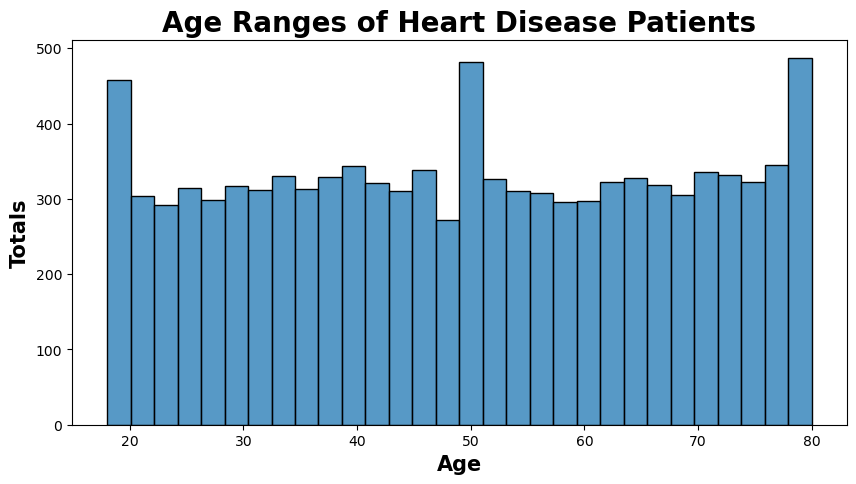

In [63]:
# Plots age ranges in the data.

sns.histplot(heart_ds, x = 'Age', bins= 30)
plt.title('Age Ranges of Heart Disease Patients', fontsize = 20, weight = 'bold')
plt.xlabel('Age', fontsize = 15, weight = 'bold')
plt.ylabel('Totals', fontsize = 15, weight = 'bold')
plt.show()

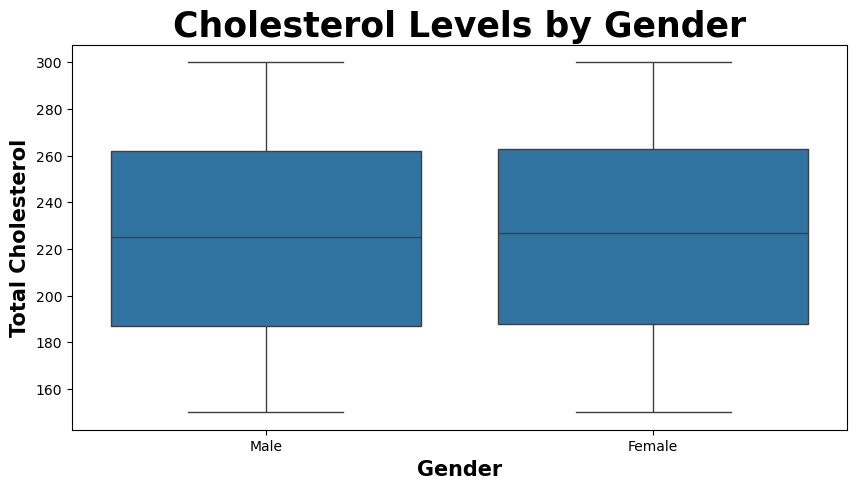

In [64]:
# Plot to show Cholesterol levels by gender.

sns.boxplot(heart_ds, x = 'Gender', y = 'Cholesterol Level')
plt.title('Cholesterol Levels by Gender', fontsize = 25, weight = 'bold' )
plt.xlabel('Gender', fontsize = 15, weight = 'bold')
plt.ylabel('Total Cholesterol', fontsize = 15, weight = 'bold')
plt.show()

<h1><center>Preprocessing Data</center></h1>

In [ ]:
# Creates label encoder instance.
le = LabelEncoder()

In [ ]:
# Convert columns to hierarchical values.

heart_ds['Exercise Habits'] = le.fit_transform(heart_ds['Exercise Habits'])
heart_ds['Sress Level'] = le.fit_transform(heart_ds['Stress Level'])
heart_ds['Sugar Consumption'] = le.fit_transform(heart_ds['Sugar Consumption'])


In [67]:
# Round columns to two decimal places.

heart_ds['BMI'] = heart_ds['BMI'].round(2)
heart_ds['Sleep Hours'] = heart_ds['Sleep Hours'].round(2)
heart_ds['CRP Level'] = heart_ds['CRP Level'].round(2)
heart_ds['Homocysteine Level'] = heart_ds['Homocysteine Level'].round(2)

In [68]:
# Convert categorical data into numerical.

heart_ds['Gender'].replace({'Male': 1, 'Female': 0}, inplace = True)
heart_ds['Smoking'].replace({'Yes': 1, 'No': 0}, inplace = True)
heart_ds['Family Heart Disease'].replace({'Yes': 1, 'No': 0}, inplace = True)
heart_ds['Diabetes'].replace({'Yes': 1, 'No': 0}, inplace = True)
heart_ds['High Blood Pressure'].replace({'Yes': 1, 'No': 0}, inplace = True)
heart_ds['High LDL Cholesterol'].replace({'Yes': 1, 'No': 0}, inplace = True)
heart_ds['Low HDL Cholesterol'].replace({'Yes': 1, 'No': 0}, inplace = True)
heart_ds['Heart Disease Status'].replace({'Yes': 1, 'No': 0}, inplace = True)



In [82]:
# Drop unneeded column.

heart_ds.drop('Alcohol Consumption', axis=1, inplace=True)

KeyError: "['Alcohol Consumption'] not found in axis"

In [81]:
# View first five rows of dataset. 

heart_ds.head()

,Age,Gender,Blood Pressure,Cholesterol Level,Exercise Habits,Smoking,Family Heart Disease,Diabetes,BMI,High Blood Pressure,...,High LDL Cholesterol,Stress Level,Sleep Hours,Sugar Consumption,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Heart Disease Status,Sress Level
0,56.0,1.0,153.0,155.0,0,1.0,1.0,0.0,24.99,1.0,...,0.0,Medium,7.63,2,342.0,NaN,12.97,12.39,0,2
1,69.0,0.0,146.0,286.0,0,0.0,1.0,1.0,25.22,0.0,...,0.0,High,8.74,2,133.0,157.0,9.36,19.30,0,0
2,46.0,1.0,126.0,216.0,1,0.0,0.0,0.0,29.86,0.0,...,1.0,Low,4.44,1,393.0,92.0,12.71,11.23,0,1
3,32.0,0.0,122.0,293.0,0,1.0,1.0,0.0,24.13,1.0,...,1.0,High,5.25,0,293.0,94.0,12.51,5.96,0,0
4,60.0,1.0,166.0,242.0,1,1.0,1.0,1.0,20.49,1.0,...,0.0,High,7.03,0,263.0,154.0,10.38,8.15,0,0


<h1><center>Build Model</center></h1>

In [ ]:
# Split data in X and y variables.

X = heart_ds.drop(columns=('Heart Disease Status'))
y = heart_ds['Heart Disease Status']

In [ ]:
# Create a dataframe of numerical values.

num_cols = X.select_dtypes(include = ['int64', 'float64']).columns

In [73]:
preproccess = ColumnTransformer(
    transformers = [
        ('num', Pipeline([
            ('impute', SimpleImputer(strategy = 'median')),
            ('scale', StandardScaler())
        ]), num_cols)
        
        ])

In [74]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state=0, stratify = y)

In [75]:
print(f"The dimensions of X_train is: \n {X_train.shape}")
print(f"The dimensions of X_test is: \n {X_test.shape}")
print(f"The dimensions of y_train is: \n {y_train.shape}")
print(f"The dimensions of y_test is: \n {y_test.shape}")

The dimensions of X_train is: 
 (8000, 20)
The dimensions of X_test is: 
 (2000, 20)
The dimensions of y_train is: 
 (8000,)
The dimensions of y_test is: 
 (2000,)


In [76]:
X_train = preproccess.fit_transform(X_train)
X_test = preproccess.transform(X_test)

In [77]:
model = Sequential([
    Dense(32, activation = 'relu', input_shape = (X_train.shape[1],)), Dropout(0.2),
    Dense(16, activation = 'relu'), Dropout(0.2),
    Dense(1, activation = 'sigmoid')
])

In [78]:
model.compile(
    optimizer= 'adam',
    loss = 'binary_crossentropy',
    metrics = ['accuracy']
)

In [79]:
history = model.fit(
    X_train,
    y_train,
    epochs = 30,
    batch_size = 32,
    validation_split = 0.2,
    verbose = 1
)

Epoch 1/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 786us/step - accuracy: 0.7117 - loss: 0.5864 - val_accuracy: 0.8169 - val_loss: 0.4891
Epoch 2/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 493us/step - accuracy: 0.7953 - loss: 0.5232 - val_accuracy: 0.8169 - val_loss: 0.4841
Epoch 3/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 477us/step - accuracy: 0.7958 - loss: 0.5199 - val_accuracy: 0.8169 - val_loss: 0.4851
Epoch 4/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 478us/step - accuracy: 0.7956 - loss: 0.5088 - val_accuracy: 0.8169 - val_loss: 0.4810
Epoch 5/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 475us/step - accuracy: 0.7958 - loss: 0.5123 - val_accuracy: 0.8169 - val_loss: 0.4810
Epoch 6/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 473us/step - accuracy: 0.7958 - loss: 0.5099 - val_accuracy: 0.8169 - val_loss: 0.4849
Epoch 7/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 473us/step - accuracy: 0.7958 - loss: 0.5102 - val_accuracy: 0.8169 - val_loss: 0.4824
Epoch 8/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 472us/step - accuracy: 0.7958 - loss: 0.5079 - 

In [80]:
y_pred = (model.predict(X_test) > 0.5).astype(int)

print("Accuracy:", accuracy_score(y_test,y_pred))

print(classification_report(y_test,y_pred))

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 477us/step
Accuracy: 0.8
              precision    recall  f1-score   support

           0       0.80      1.00      0.89      1600
           1       0.00      0.00      0.00       400

    accuracy                           0.80      2000
   macro avg       0.40      0.50      0.44      2000
weighted avg       0.64      0.80      0.71      2000

